This notebook has code to reproduce the Rutor Glacier analysis

In [1]:
import numpy as np, pandas as pd
from tools.core import *
from tools.clustering import *

from scipy.spatial.distance import pdist, squareform

import matplotlib as mpl
import matplotlib.pyplot as plt, seaborn as sns

The original data is from Caccianaga et al. (https://doi.org/10.1111/j.0030-1299.2006.14107.x). We obtain it from the R package adiv (https://cran.r-project.org/web/packages/adiv/index.html).

In [2]:
df_abund = pd.read_csv("data/rutor_glacier/Abund.csv", index_col=0)
df_traits = pd.read_csv("data/rutor_glacier/Traits.csv", index_col=0).iloc[:, :6]
df_traits = df_traits.apply(lambda x: (x-x.mean())/x.std())

ground_truth = np.array([0]*17 + [1]*32 + [2]*10) # Early / Mid / Late stage

We construct a similarity matrix using the traits

In [3]:
emb = df_traits.to_numpy()
D = squareform( pdist(emb, metric='euclidean') )

Z = 1.0 - D/D.max()
np.linalg.eigvalsh(Z).min()

0.06645297536338188

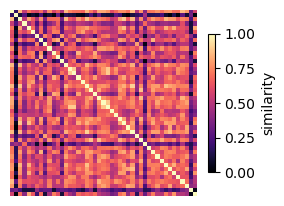

In [4]:
fig, ax = plt.subplots(1,1,figsize=(3, 3))

plt.colorbar(
    ax.imshow(Z, vmin=0, vmax=1, cmap='magma'), ax=ax, label='similarity', shrink=0.6
)
ax.set_axis_off()

# Analysis

In [5]:
arr_vectors = np.asarray(df_abund.to_numpy(), dtype=float)
arr_vectors /= arr_vectors.sum(axis=1)[:, np.newaxis] 

Empirical beta diversities

In [6]:
functional = [get_bregman_information( Z, 2, (arr_vectors[ground_truth==i])/(arr_vectors[ground_truth==i].sum()) ) for i in [0,1,2]]
taxonomic = [get_bregman_information( np.eye(45), 2, (arr_vectors[ground_truth==i])/(arr_vectors[ground_truth==i].sum()) ) for i in [0,1,2]]

In [7]:
functional, taxonomic

([0.030336083201427666, 0.01385846768332133, 0.014033158458733985],
 [0.05214412062118268, 0.03507304958955004, 0.04481519860709571])

Null model

In [8]:
rng = np.random.default_rng(42)

null_data = []
for stage, n in enumerate([17,32,10]):
    null_bi = []
    for _ in range(1000):
        null_joint = rng.choice(arr_vectors, n)
        null_joint /= null_joint.sum()
        null_bi.append(get_bregman_information(Z, 2, null_joint))
    null_data.append(null_bi)

null_data_i = []
for stage, n in enumerate([17,32,10]):
    null_bi = []
    for _ in range(1000):
        null_joint = rng.choice(arr_vectors, n)
        null_joint /= null_joint.sum()
        null_bi.append(get_bregman_information(np.eye(45), 2, null_joint))
    null_data_i.append(null_bi)

Text(0.02, 0.5, 'proportion of random samples')

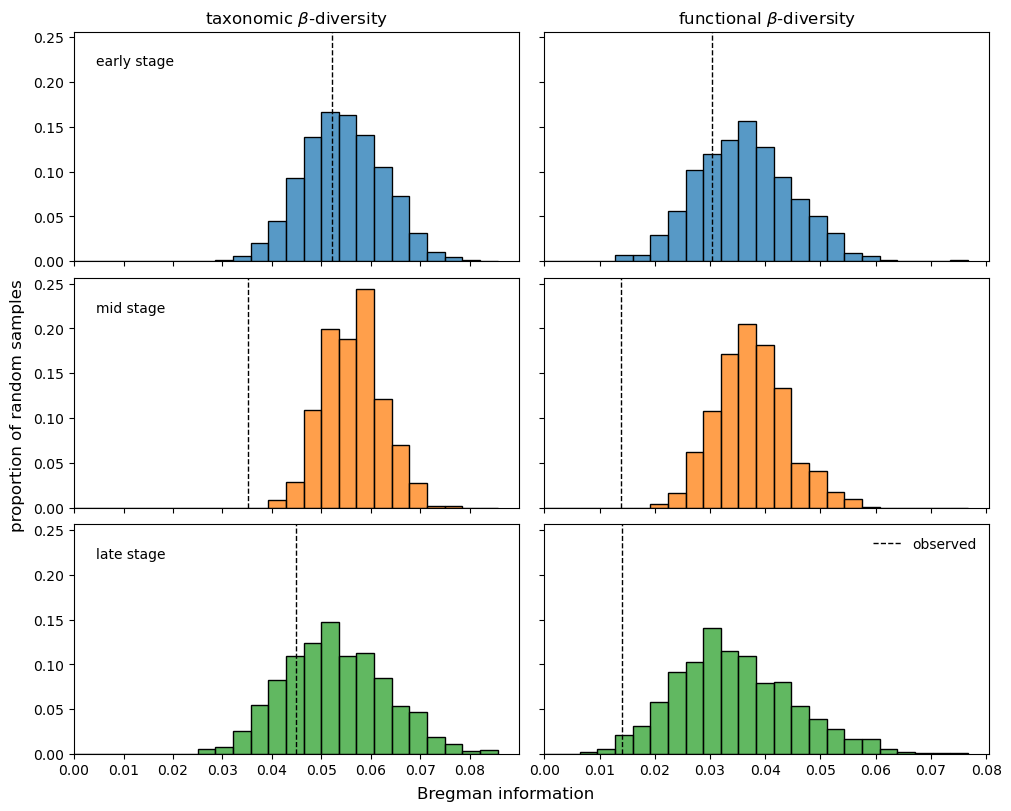

In [9]:
fig, axes = plt.subplots(3,2,figsize=(10, 8), layout='constrained', sharex='col', sharey=True)
# taxonomic
bins = np.linspace(0, np.array(null_data_i).max(), 25)
for stage, txt in enumerate(['early stage', 'mid stage', 'late stage']):
    sns.histplot(
        null_data_i[stage],
        ax = axes[stage, 0],
        color = sns.color_palette()[stage],
        bins = bins,
        stat = 'proportion',
    )
    axes[stage, 0].axvline(taxonomic[stage], ls='--', lw=1, color='black', label='observed')
    axes[stage, 0].set_xlim(0, None)
    axes[stage, 0].set_ylabel('')
    fig.text(.05,.90, txt, transform=axes[stage, 0].transAxes, ha='left', va='top')

axes[0,0].set_title(r'taxonomic $\beta$-diversity')

bins = np.linspace(0, np.array(null_data).max(), 25)
for stage, txt in enumerate(['early stage', 'mid stage', 'late stage']):
    sns.histplot(
        null_data[stage],
        ax = axes[stage, 1],
        color = sns.color_palette()[stage],
        bins = bins,
        stat = 'proportion',
    )
    axes[stage, 1].axvline(functional[stage], ls='--', lw=1., color='black', label='observed')
    axes[stage, 1].set_xlim(0, None)
    axes[stage, 1].set_ylabel('')

axes[2,1].legend(frameon=False, loc='upper right')
axes[0,1].set_title(r'functional $\beta$-diversity')

fig.supxlabel('Bregman information')
fig.supylabel('proportion of random samples')